In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn import linear_model
from sklearn.metrics import r2_score
from scipy.stats import ttest_ind

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Student_Performance.csv to Student_Performance.csv


In [ ]:
df = pd.read_csv('Student_Performance.csv')
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [ ]:
df.tail()
# menampilkan 5 data paling bawah

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [ ]:
# merangkum data
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [ ]:
cdf = df[['Previous Scores','Sleep Hours','Sample Question Papers Practiced','Performance Index']]
cdf.head(10)

,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,99,9,1,91.0
1,82,4,2,65.0
2,51,7,2,45.0
3,52,5,2,36.0
4,75,8,5,66.0
5,78,9,6,61.0
6,73,5,6,63.0
7,45,4,6,42.0
8,77,8,2,61.0
9,89,4,0,69.0


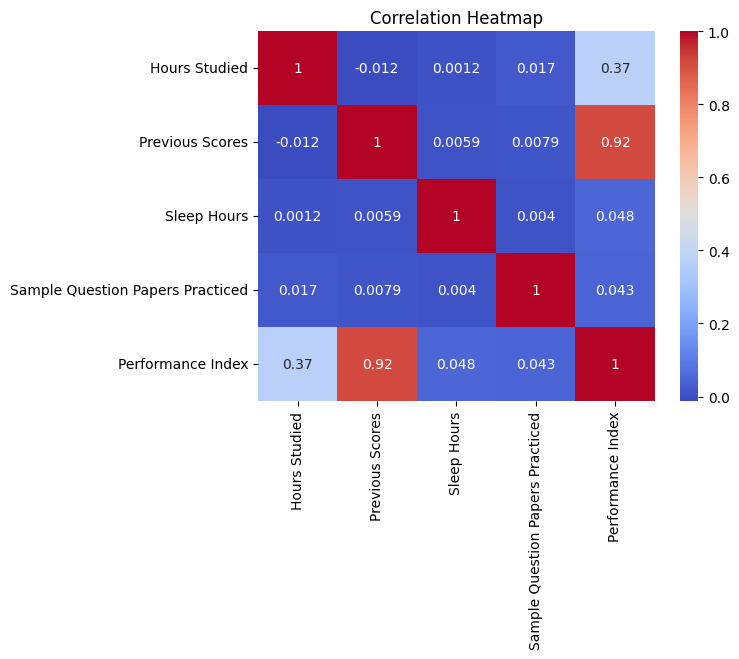

In [ ]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()
# mengetahui fitur mana yang paling berpengaruh terhadap Performance Index.

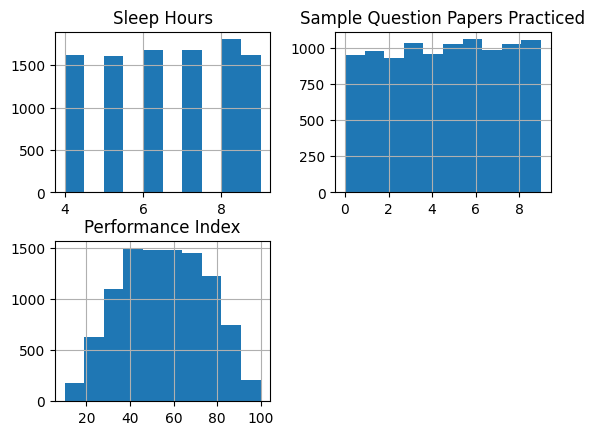

In [ ]:
viz = cdf[['Sleep Hours','Sample Question Papers Practiced','Performance Index']]
viz.hist()
plt.show()

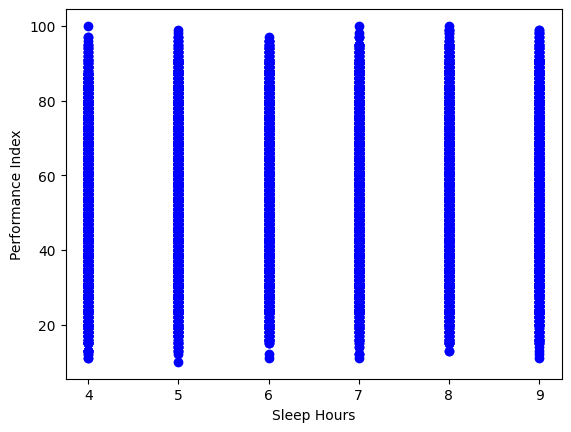

In [ ]:
plt.scatter(cdf['Sleep Hours'], cdf['Performance Index'], color='blue')
plt.xlabel("Sleep Hours")
plt.ylabel("Performance Index")
plt.show()

In [ ]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

In [ ]:
print(train.columns)

Index(['Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced',
       'Performance Index'],
      dtype='object')


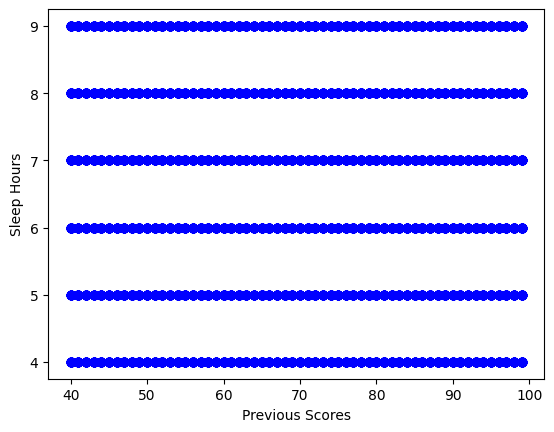

In [ ]:
plt.scatter(train['Previous Scores'], train['Sleep Hours'], color='blue')
plt.xlabel("Previous Scores")
plt.ylabel("Sleep Hours")
plt.show()

In [ ]:
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['Previous Scores']])
train_y = np.asanyarray(train[['Performance Index']])
regr.fit (train_x, train_y)

# The coefficients
print ('Coefficients: ', regr.coef_)
print ('Intercept: ',regr.intercept_)

Coefficients:  [[1.00994913]]
Intercept:  [-14.87645192]


Text(0, 0.5, 'Performance Index')

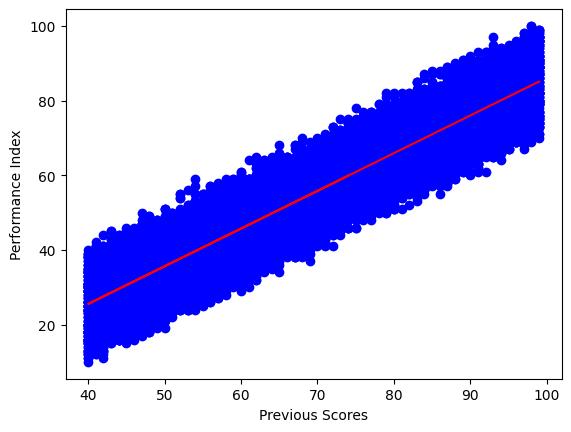

In [ ]:
plt.scatter(train['Previous Scores'], train['Performance Index'], color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("Previous Scores")
plt.ylabel("Performance Index")

In [ ]:
test_x = np.asanyarray(test[['Previous Scores']])
test_y = np.asanyarray(test[['Performance Index']])
test_y_ = regr.predict(test_x)

print("Mean absolute error: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Residual sum of squares (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y_ , test_y) )

Mean absolute error: 6.58
Residual sum of squares (MSE): 59.44
R2-score: 0.80
